In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import shap


In [2]:
%pip install imbalanced-learn seaborn xgboost catboost shap


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [4]:
df = pd.read_csv('train.csv')
print(df.head())

   ID  A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  A7_Score  \
0   1         1         0         1         0         1         0         1   
1   2         0         0         0         0         0         0         0   
2   3         1         1         1         1         1         1         1   
3   4         0         0         0         0         0         0         0   
4   5         0         0         0         0         0         0         0   

   A8_Score  A9_Score  ...  gender       ethnicity jaundice austim  \
0         0         1  ...       f               ?       no     no   
1         0         0  ...       m               ?       no     no   
2         1         1  ...       m  White-European       no    yes   
3         0         0  ...       f               ?       no     no   
4         0         0  ...       m               ?       no     no   

   contry_of_res used_app_before     result     age_desc  relation Class/ASD  
0        Austria         

In [5]:
df['ethnicity'].value_counts()


ethnicity
White-European     257
?                  203
Middle Eastern      97
Asian               67
Black               47
South Asian         34
Pasifika            32
Others              29
Latino              17
Hispanic             9
Turkish              5
others               3
Name: count, dtype: int64

In [6]:
df['relation'].value_counts()


relation
Self                        709
?                            40
Parent                       29
Relative                     18
Others                        2
Health care professional      2
Name: count, dtype: int64

In [7]:
df = df.replace({'yes':1, 'no':0, '?':'Others', 'others':'Others'})


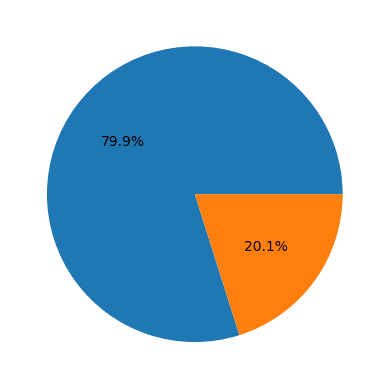

In [8]:
plt.pie(df['Class/ASD'].value_counts().values, autopct='%1.1f%%')
plt.show()


In [9]:
ints = []
objects = []
floats = []

for col in df.columns:
  if pd.api.types.is_integer_dtype(df[col]):
    ints.append(col)
  elif df[col].dtype == object:
    objects.append(col)
  else:
    floats.append(col)

for i in ints:
    print(i)

ID
A1_Score
A2_Score
A3_Score
A4_Score
A5_Score
A6_Score
A7_Score
A8_Score
A9_Score
A10_Score
jaundice
austim
used_app_before
Class/ASD


In [10]:
ints.remove('ID')
ints.remove('Class/ASD')

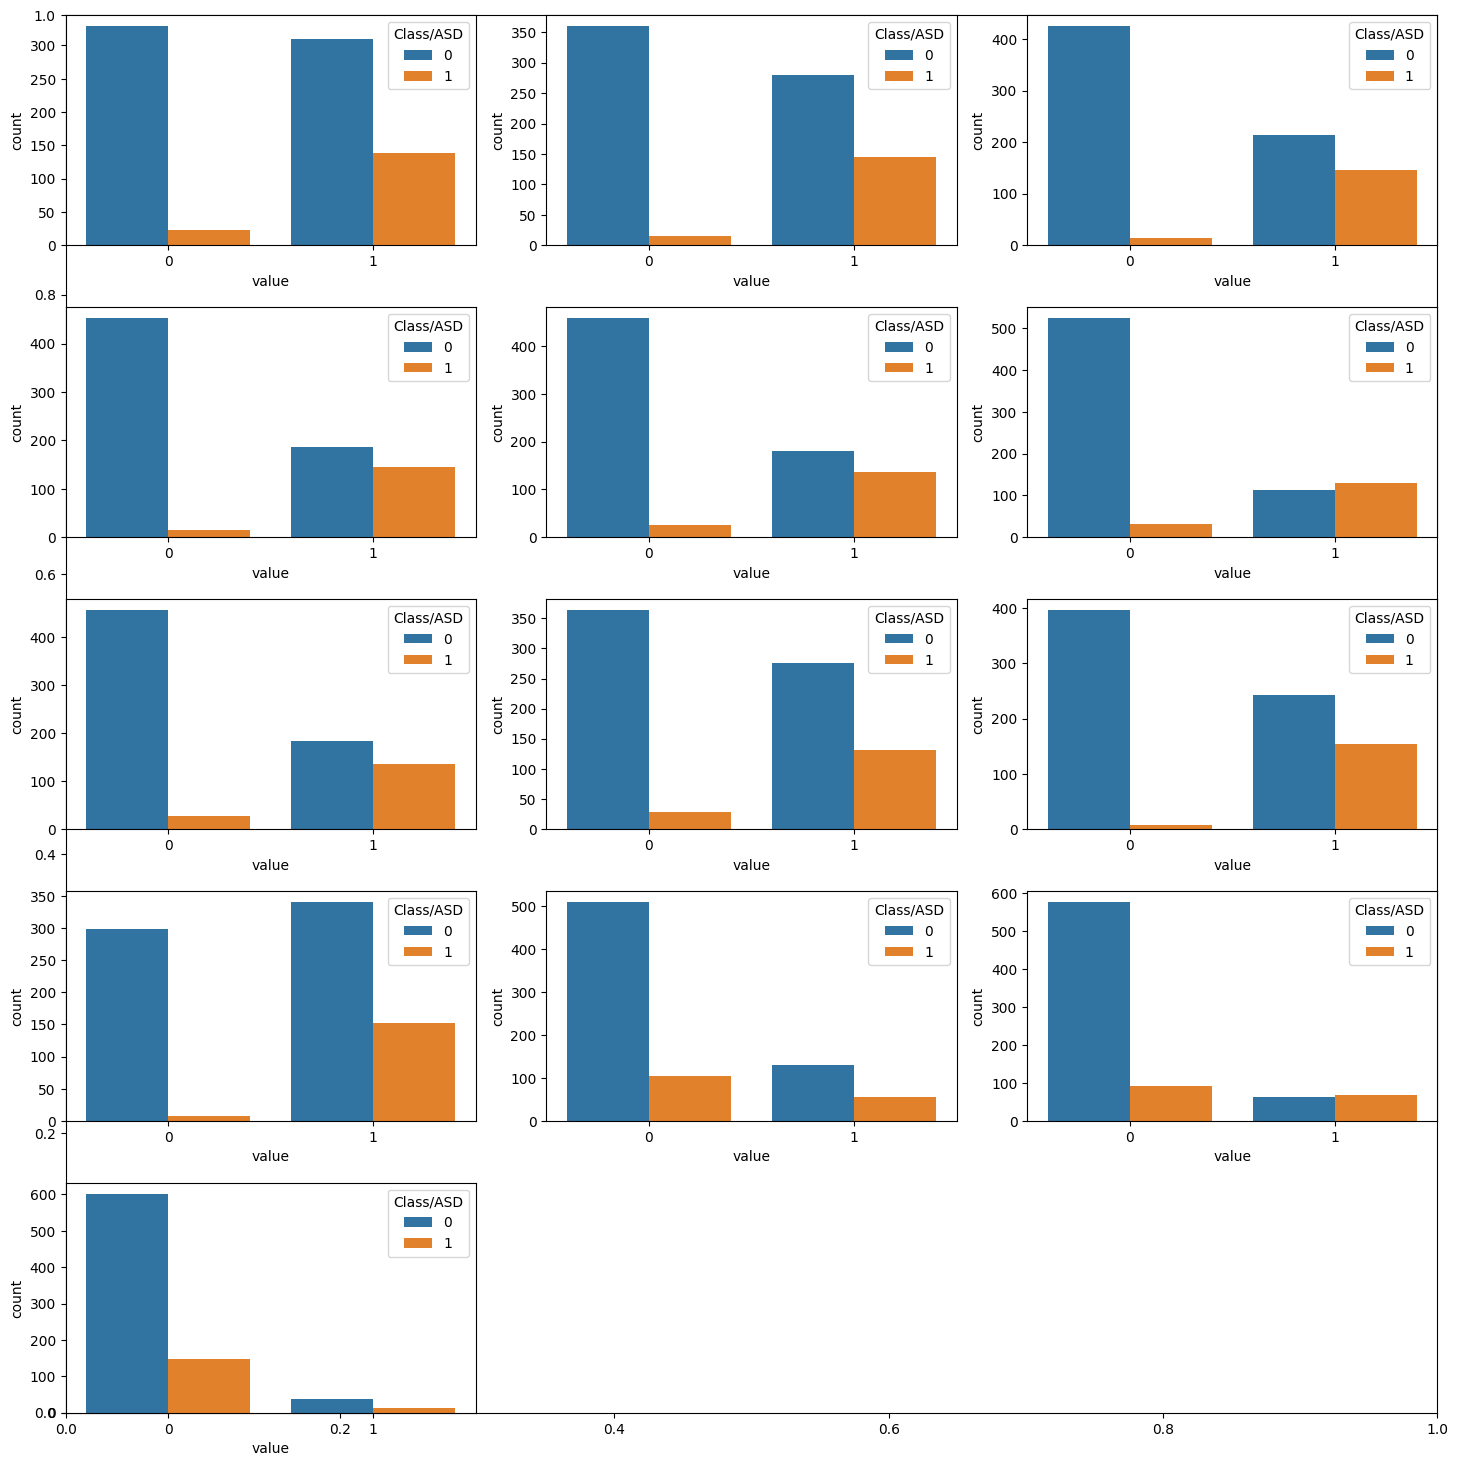

In [11]:
# Convert the data to long-form using melt
df_melted = df.melt(id_vars=['ID', 'Class/ASD'], value_vars=ints, var_name='col', value_name='value')

plt.subplots(figsize=(15,15))

for i, col in enumerate(ints):
  plt.subplot(5,3,i+1)
  # Use the melted DataFrame and specify x and hue
  sb.countplot(x='value', hue='Class/ASD', data=df_melted[df_melted['col'] == col])

plt.tight_layout()
plt.show()

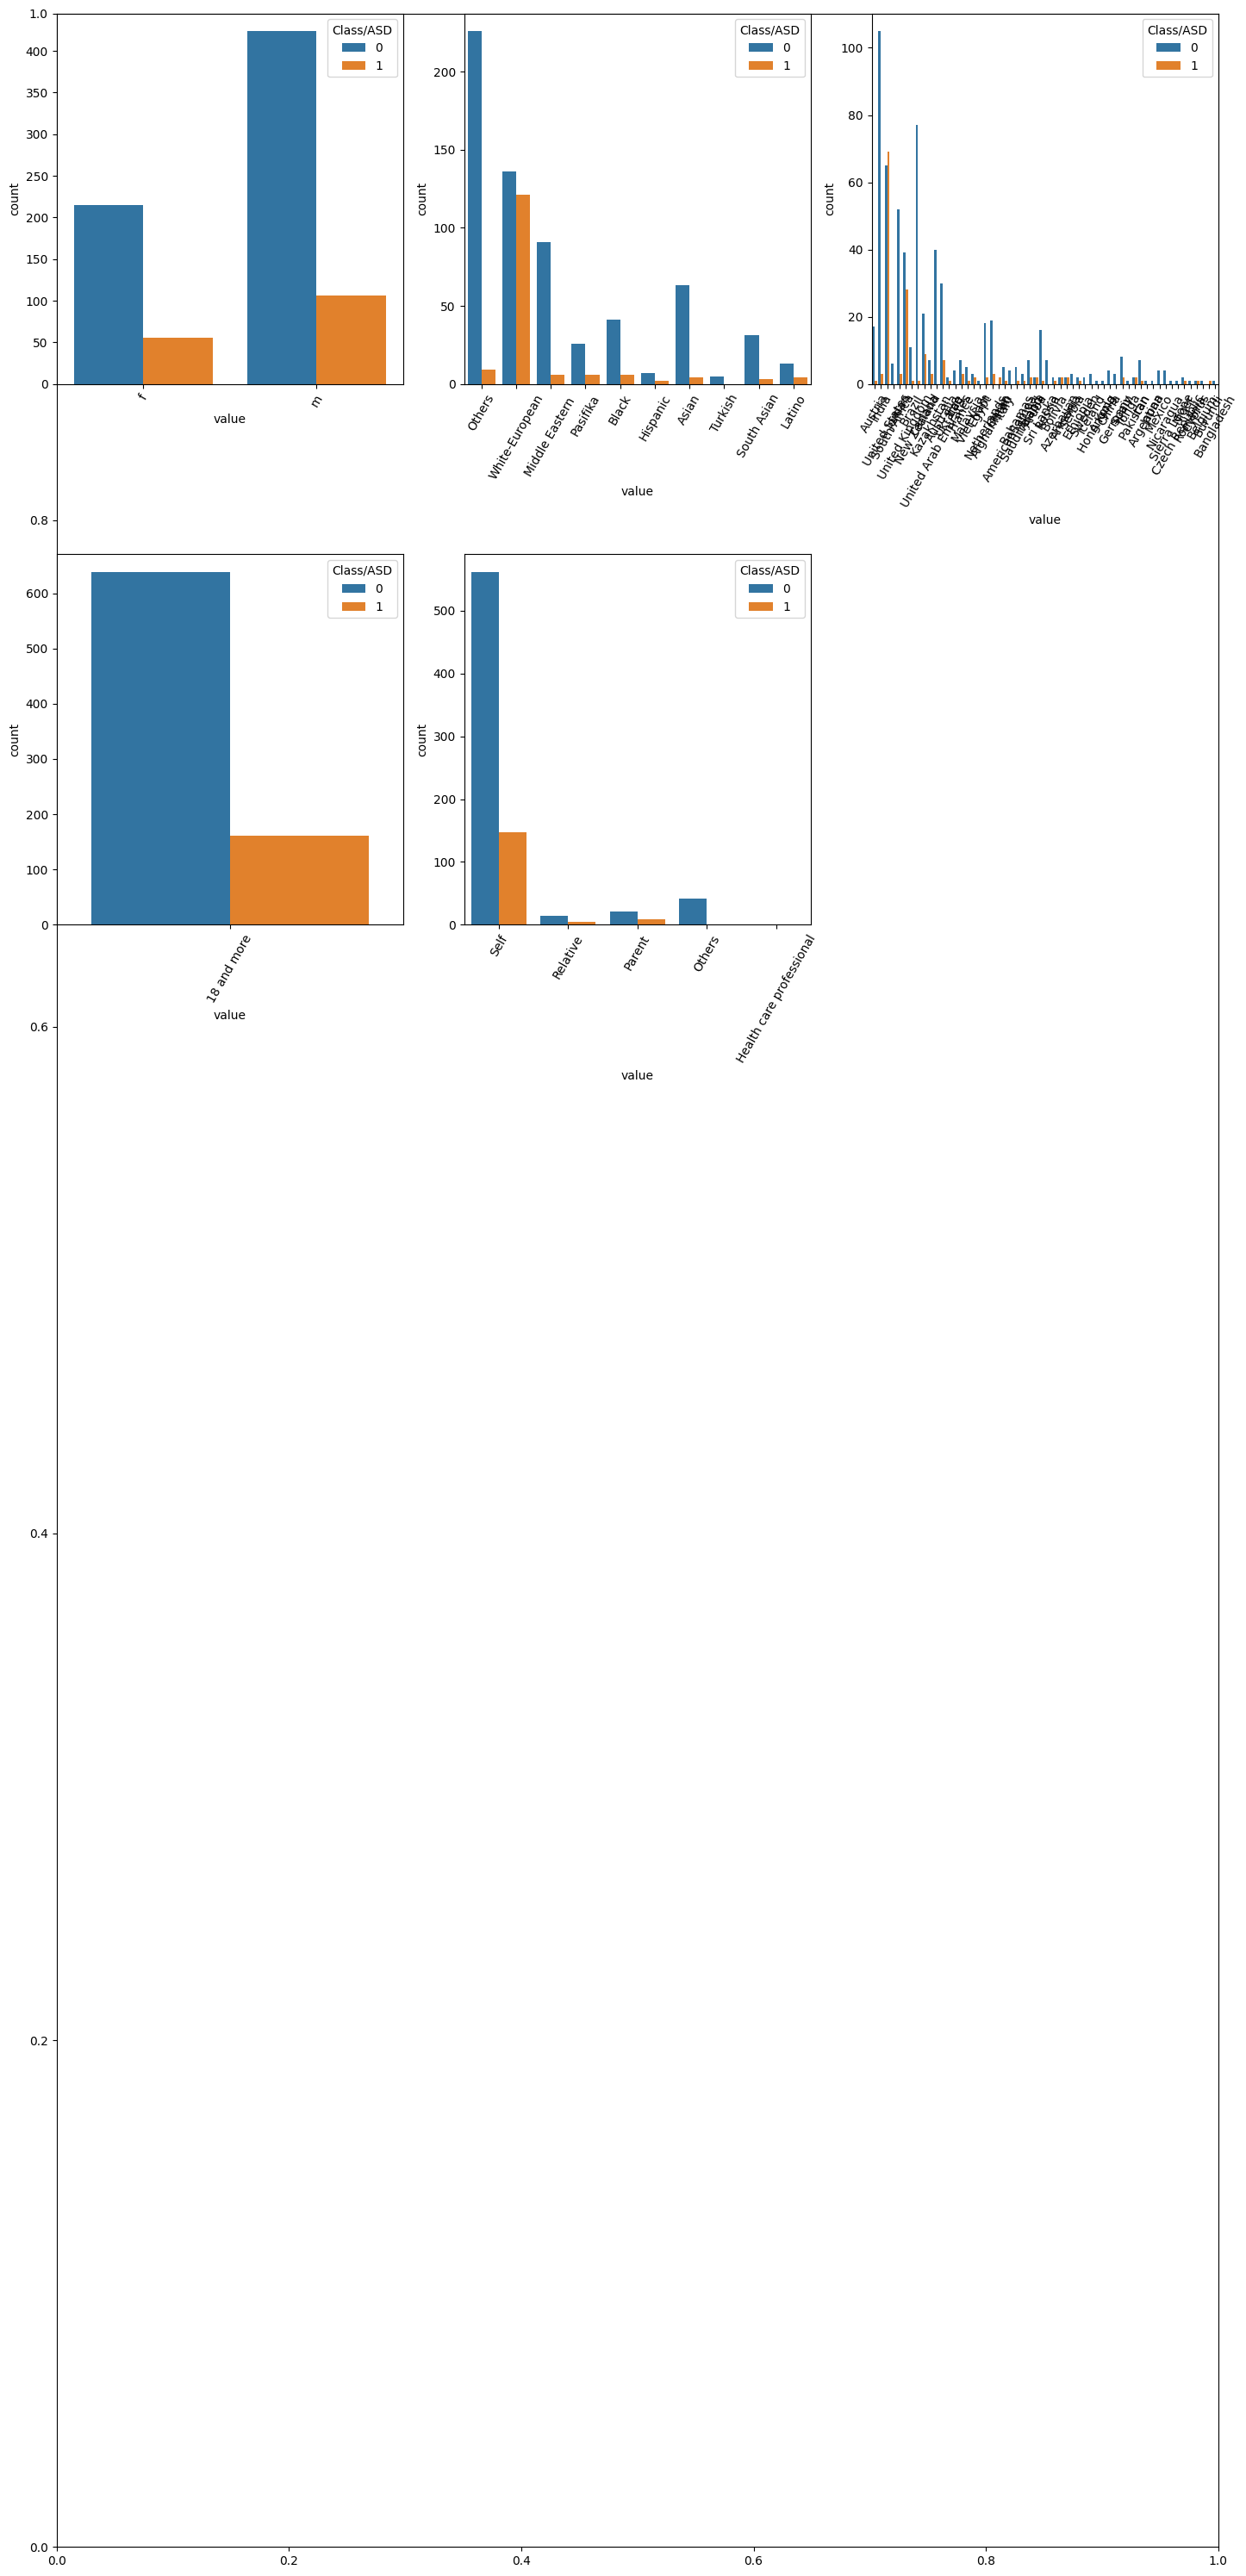

In [12]:
plt.subplots(figsize=(15, 30))

for i, col in enumerate(objects):
    plt.subplot(5, 3, i+1)
    # Convert the data to long-form for the specific column
    df_melted = df.melt(id_vars=['Class/ASD'], value_vars=[col], var_name='col', value_name='value')

    # Use the melted DataFrame and specify x and hue
    sb.countplot(x='value', hue='Class/ASD', data=df_melted)
    plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

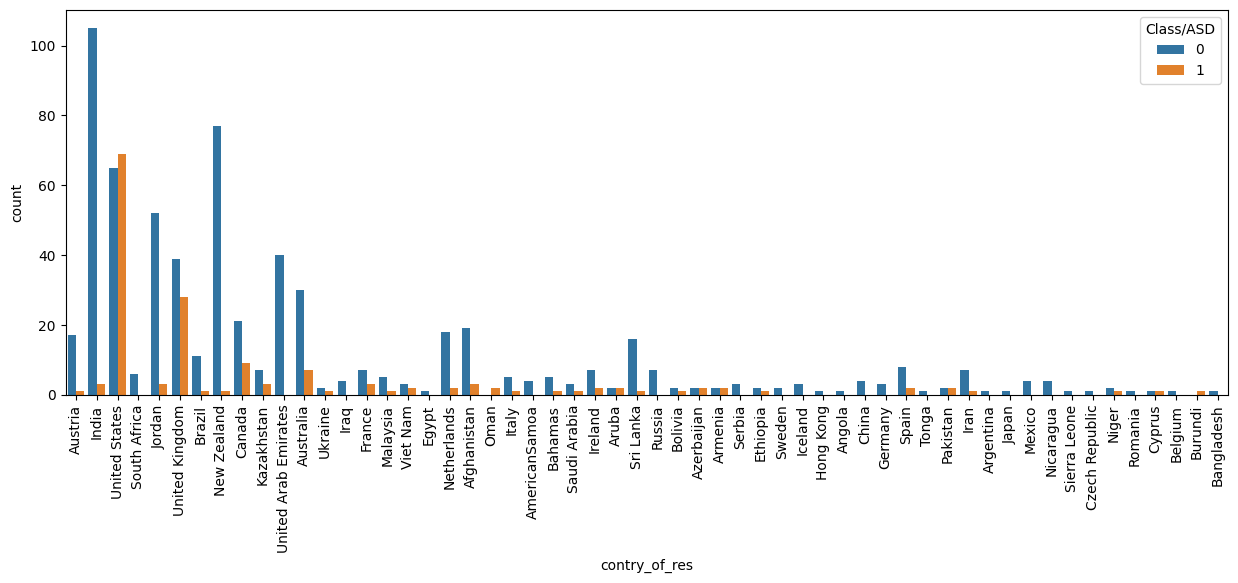

In [13]:
plt.figure(figsize=(15,5))
sb.countplot(data=df, x='contry_of_res', hue='Class/ASD')
plt.xticks(rotation=90)
plt.show()


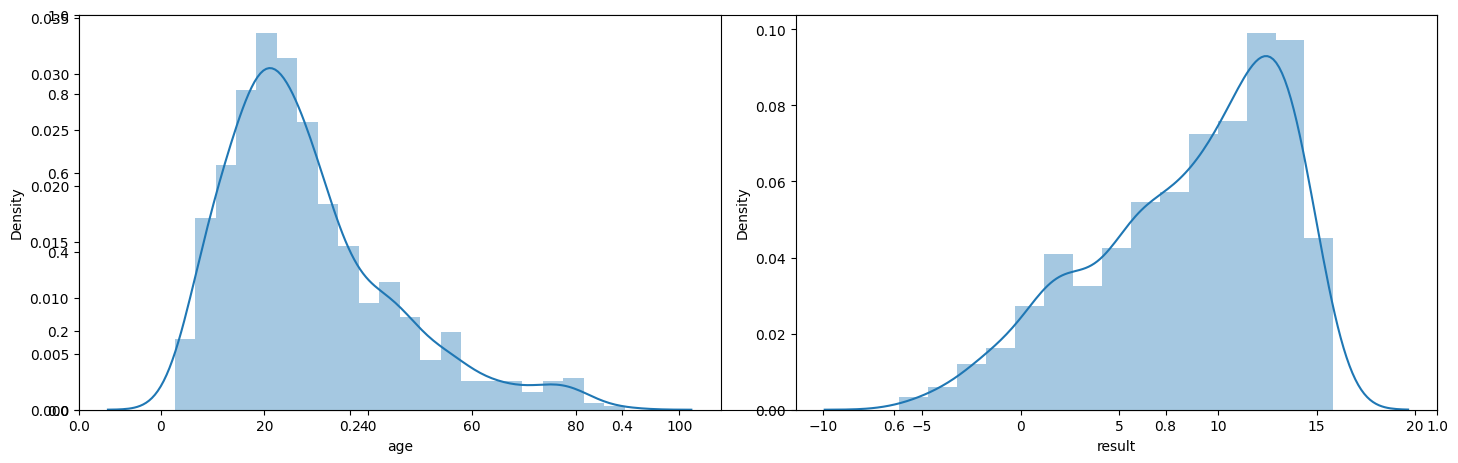

In [14]:
plt.subplots(figsize=(15,5))

for i, col in enumerate(floats):
  plt.subplot(1,2,i+1)
  sb.distplot(df[col])
plt.tight_layout()
plt.show()


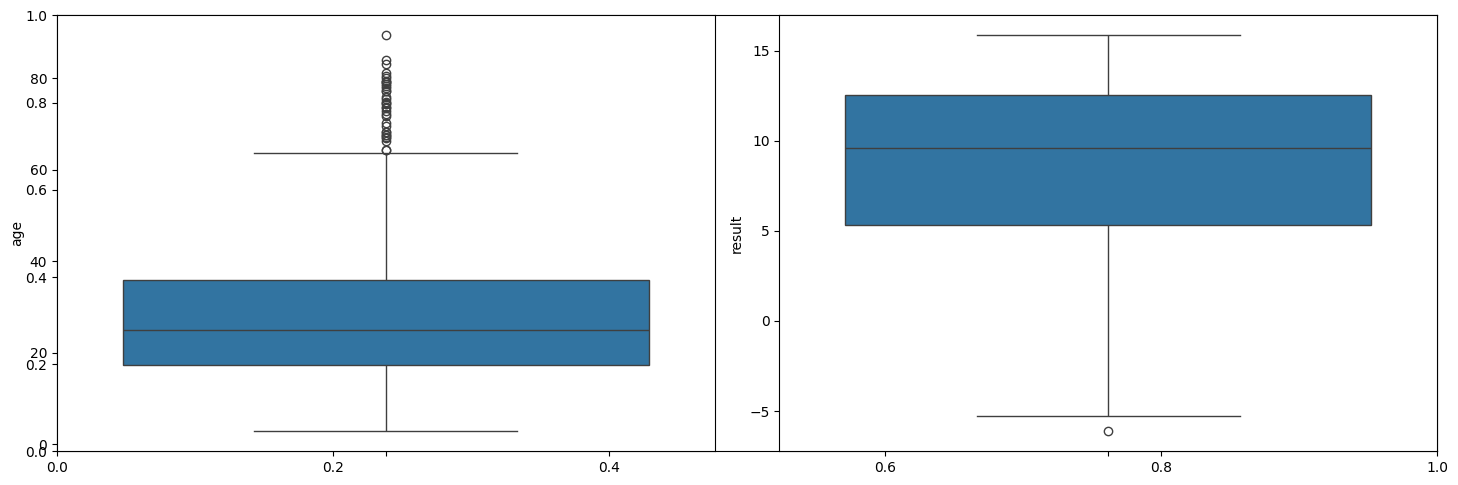

In [15]:
plt.subplots(figsize=(15,5))

for i, col in enumerate(floats):
  plt.subplot(1,2,i+1)
  sb.boxplot(df[col])
plt.tight_layout()
plt.show()


In [16]:
df = df[df['result']>-5]
df.shape


(798, 22)

In [17]:
# This functions make groups by taking
# the age as a parameter
def convertAge(age):
    if age < 4:
        return 'Toddler'
    elif age < 12:
        return 'Kid'
    elif age < 18:
        return 'Teenager'
    elif age < 40:
        return 'Young'
    else:
        return 'Senior'

df['ageGroup'] = df['age'].apply(convertAge)


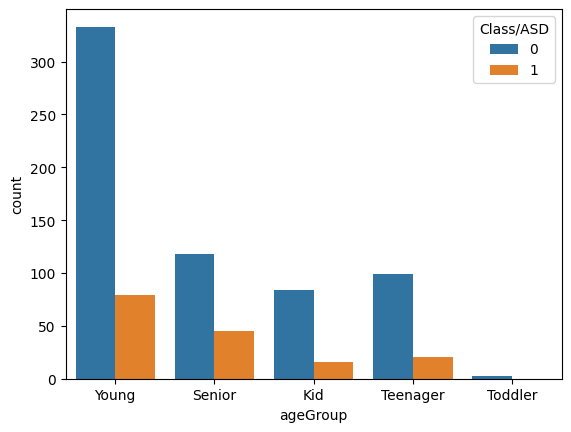

In [18]:
sb.countplot(x=df['ageGroup'], hue=df['Class/ASD'])
plt.show()


In [19]:
def add_feature(data):

  # Creating a column with all values zero
  data['sum_score'] = 0
  for col in data.loc[:,'A1_Score':'A10_Score'].columns:

    # Updating the 'sum_score' value with scores
    # from A1 to A10
    data['sum_score'] += data[col]

  # Creating a random data using the below three columns
  data['ind'] = data['austim'] + data['used_app_before'] + data['jaundice']

  return data

df = add_feature(df)


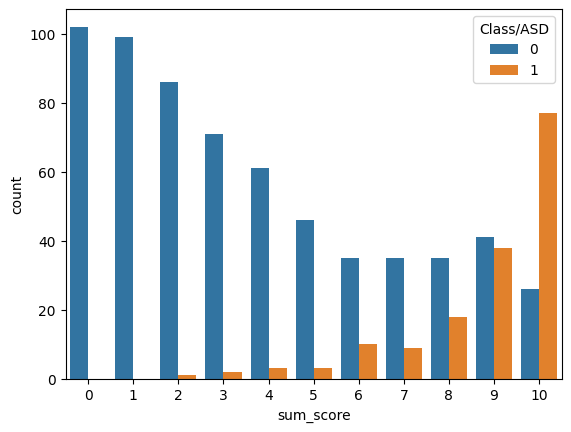

In [20]:
sb.countplot(x=df['sum_score'], hue=df['Class/ASD'])
plt.show()


In [21]:
# Applying log transformations to remove the skewness of the data.
df['age'] = df['age'].apply(lambda x: np.log(x))


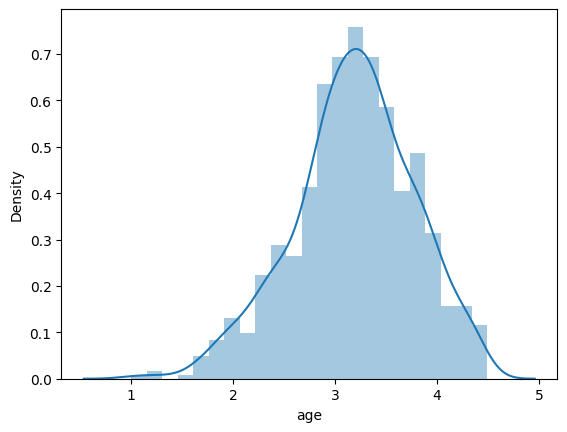

In [22]:
sb.distplot(df['age'])
plt.show()


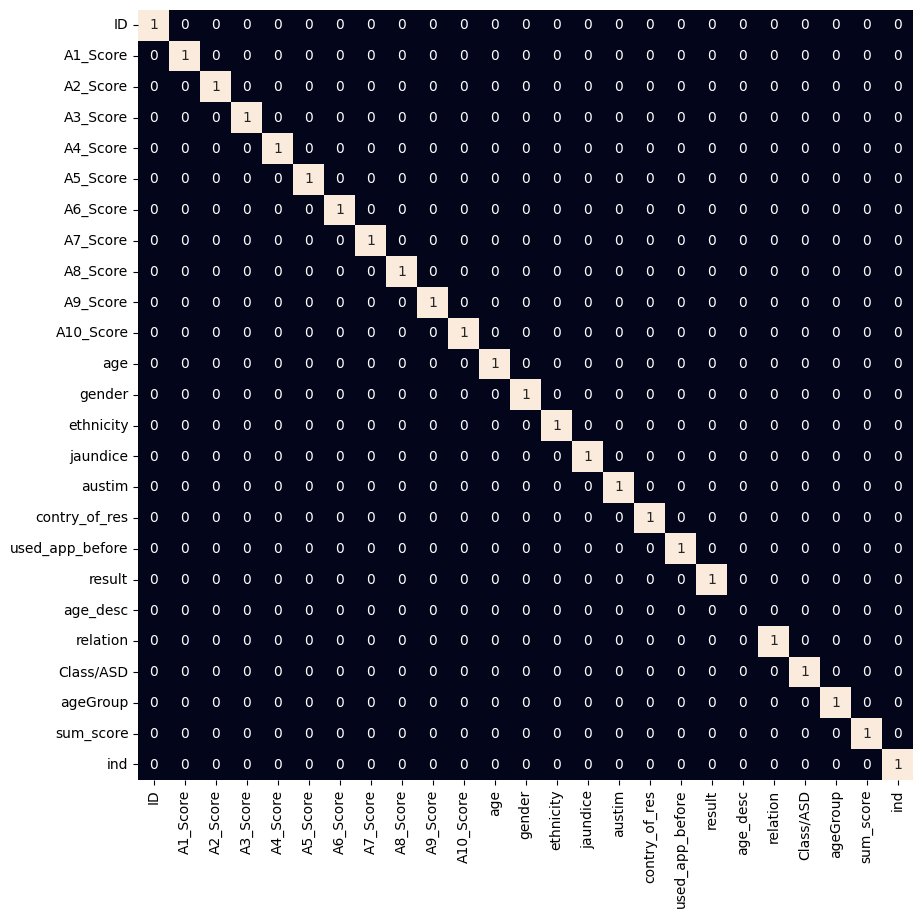

In [23]:
def encode_labels(data):
    for col in data.columns:

      # Here we will check if datatype
      # is object then we will encode it
      if data[col].dtype == 'object':
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])

    return data

df = encode_labels(df)

# Making a heatmap to visualize the correlation matrix
plt.figure(figsize=(10,10))
sb.heatmap(df.corr() > 0.8, annot=True, cbar=False)
plt.show()


In [24]:
removal = ['ID', 'age_desc', 'used_app_before', 'austim']
features = df.drop(removal + ['Class/ASD'], axis=1)
target = df['Class/ASD']


In [25]:
# Change 1: Fix Class Imbalance with SMOTE (Applied on training set only)
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Original X_train shape: {X_train.shape}")
print(f"Resampled X_train shape: {X_train_res.shape}")


Original X_train shape: (638, 20)
Resampled X_train shape: (1028, 20)


In [26]:
# Feature Normalization with StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)
features_scaled = scaler.fit_transform(features)


In [27]:
# Change 2: Train XGBoost and CatBoost Classifiers
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, use_label_encoder=False, eval_metric="logloss", random_state=42)
xgb.fit(X_train_scaled, y_train_res)

cat = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6, verbose=0, random_state=42)
cat.fit(X_train_scaled, y_train_res)

print("XGBoost and CatBoost models trained successfully.")


XGBoost and CatBoost models trained successfully.


In [28]:
# Change 3: 5-Fold Stratified Cross-Validation Evaluation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "f1", "roc_auc"]
results = cross_validate(xgb, features_scaled, target, cv=cv, scoring=scoring)

print("XGBoost 5-Fold Stratified Cross-Validation Results:")
print(f"Accuracy: {results['test_accuracy'].mean():.4f} +/- {results['test_accuracy'].std():.4f}")
print(f"F1:       {results['test_f1'].mean():.4f} +/- {results['test_f1'].std():.4f}")
print(f"AUC:      {results['test_roc_auc'].mean():.4f} +/- {results['test_roc_auc'].std():.4f}")


XGBoost 5-Fold Stratified Cross-Validation Results:
Accuracy: 0.8333 +/- 0.0150
F1:       0.5736 +/- 0.0481
AUC:      0.8844 +/- 0.0305


In [29]:
# Change 5: Stacking Ensemble Classifier
estimators = [
    ("rf", RandomForestClassifier(n_estimators=200, random_state=42)),
    ("xgb", XGBClassifier(n_estimators=300, learning_rate=0.05, use_label_encoder=False, eval_metric="logloss", random_state=42))
]

stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), cv=5)
stack.fit(X_train_scaled, y_train_res)
print("Stacking Classifier trained successfully.")


Stacking Classifier trained successfully.


=== XGBoost Classification Report ===
              precision    recall  f1-score   support

           0       0.91      0.85      0.88       123
           1       0.59      0.73      0.65        37

    accuracy                           0.82       160
   macro avg       0.75      0.79      0.76       160
weighted avg       0.84      0.82      0.83       160

=== CatBoost Classification Report ===
              precision    recall  f1-score   support

           0       0.91      0.86      0.88       123
           1       0.60      0.70      0.65        37

    accuracy                           0.82       160
   macro avg       0.76      0.78      0.77       160
weighted avg       0.84      0.82      0.83       160

=== Stacking Classification Report ===
              precision    recall  f1-score   support

           0       0.91      0.86      0.88       123
           1       0.60      0.70      0.65        37

    accuracy                           0.82       160
   macro avg

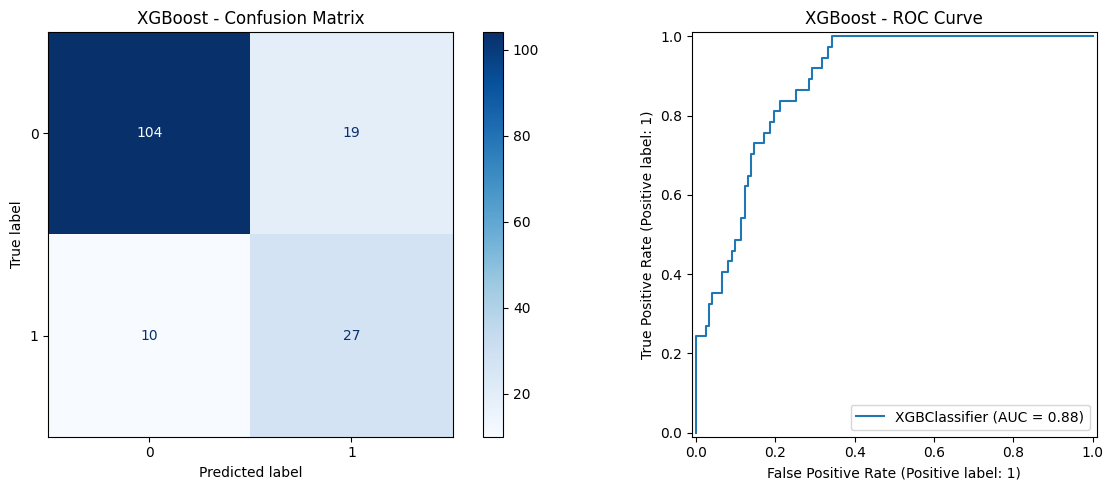

In [30]:
# Change 6: Full Evaluation Report for Every Model
models = {"XGBoost": xgb, "CatBoost": cat, "Stacking": stack}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"=== {name} Classification Report ===")
    print(classification_report(y_test, y_pred))

# Confusion Matrix and ROC Curve for XGBoost
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_estimator(xgb, X_test_scaled, y_test, ax=axes[0], cmap="Blues")
axes[0].set_title("XGBoost - Confusion Matrix")

RocCurveDisplay.from_estimator(xgb, X_test_scaled, y_test, ax=axes[1])
axes[1].set_title("XGBoost - ROC Curve")
plt.tight_layout()
plt.show()


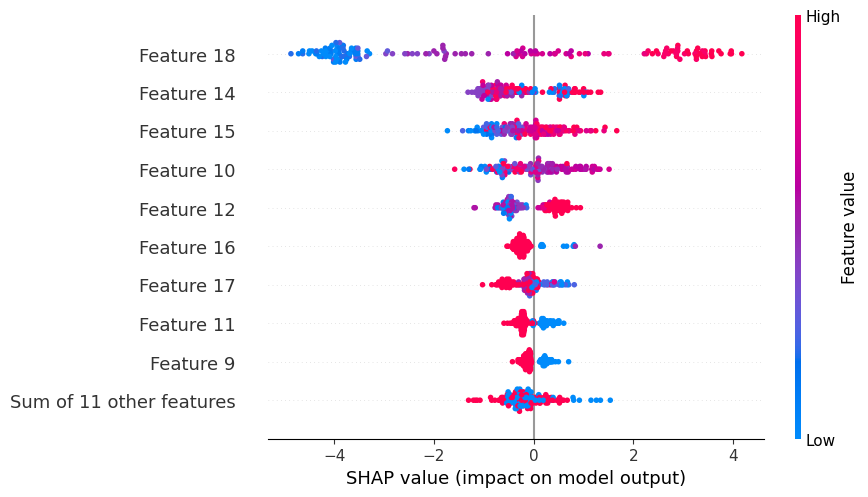

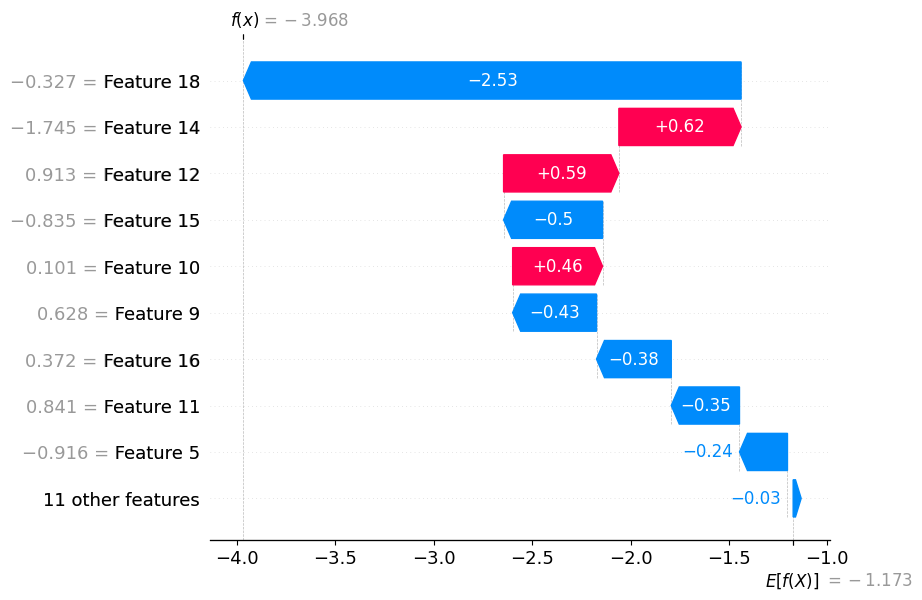

In [31]:
# Change 4: SHAP Explainability
explainer = shap.Explainer(xgb, X_train_scaled)
shap_values = explainer(X_test_scaled)

# Global Beeswarm Plot (overall feature importance)
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, show=True)

# Waterfall Plot (local explanation for a single prediction)
shap.plots.waterfall(shap_values[0], show=True)
